In [6]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import numpy as np

Dots inside: 78,264
Dots generated: 100,000
1 SE (68.27%): ±0.005217
3 SE (99.73%): ±0.015651
π approximated: 3.130560
3σ Interval: [3.114909, 3.146211]


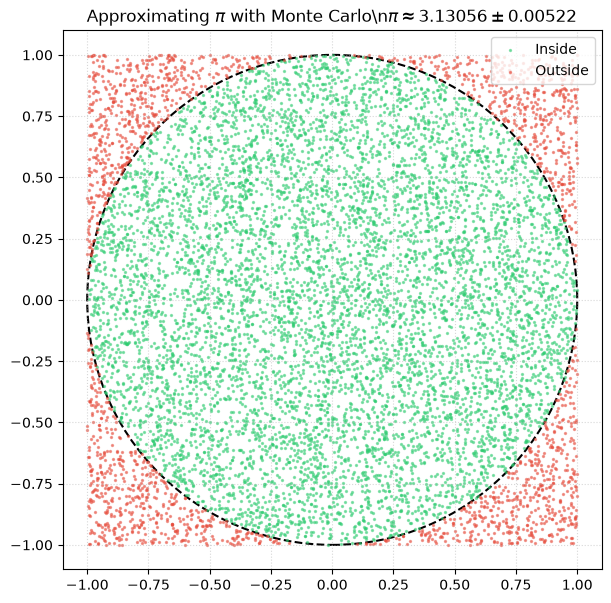

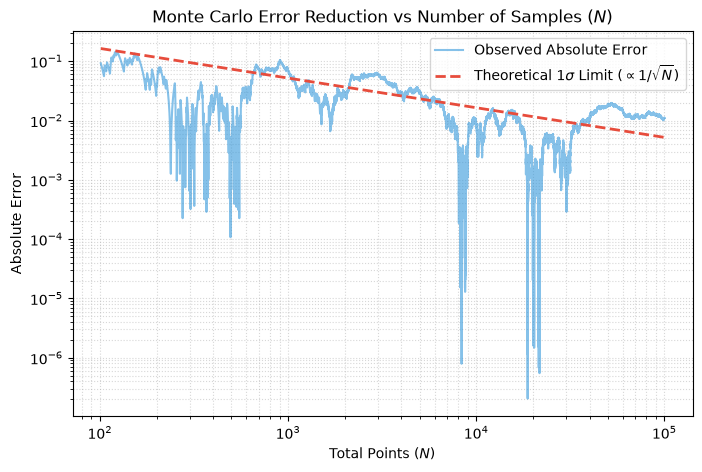

In [ ]:
# Simulation setup 
n = 100000
x = np.random.uniform(-1, 1, n)
y = np.random.uniform(-1, 1, n)

# Distance calculation
distance = x**2 + y **2
inside = distance <= 1.0

# Overall statistics
dots_inside = np.sum(inside)
dots_generated = len(x)
proportion = dots_inside / dots_generated

pi_approx = 4 * proportion

# Standard Error (SE) and 3-SE
se = 4 * np.sqrt(proportion * (1 - proportion) / n)
se_3 = se * 3

lower_limit = pi_approx - se_3
upper_limit = pi_approx + se_3

# Console output
print(f"Dots inside: {dots_inside:,}")
print(f"Dots generated: {dots_generated:,}")
print(f"1 SE (68.27%): ±{se:.6f}")
print(f"3 SE (99.73%): ±{se_3:.6f}")
print(f"π approximated: {pi_approx:.6f}")
print(f"3σ Interval: [{lower_limit:.6f}, {upper_limit:.6f}]")

# Cumulative Calculations for Error Plot
dots_inside_accumulated = np.cumsum(inside)
n_steps = np.arange(1, n + 1)

# Theoretical SE decay over time (p_theoretical = pi / 4)
pi_accumulated = 4 * (dots_inside_accumulated / n_steps)
absolute_error = np.abs(pi_accumulated - np.pi)

p_theoretical = np.pi / 4
se_theoretical = 4 * np.sqrt(p_theoretical * (1 - p_theoretical) / n_steps)

# 3. Plot 1: Circle Representation
fig_circle, draw_circle = plt.subplots(figsize=(7, 7))

draw_circle.set_aspect('equal')
draw_circle.set_xlim((-1.1, 1.1))
draw_circle.set_ylim((-1.1, 1.1))
draw_circle.set_title(rf'Approximating $\pi$ with Monte Carlo\n$\pi \approx {pi_approx:.5f} \pm {se:.5f}$')

circumference = plt.Circle((0, 0), 1.0, fill=False, color='black', linestyle='--', linewidth=1.5)
draw_circle.add_patch(circumference)

# Subsample for smooth rendering (10,000 points)
n_view = 10000
x_vis, y_vis = x[:n_view], y[:n_view]
inside_vis = inside[:n_view]

draw_circle.scatter(x_vis[inside_vis], y_vis[inside_vis], color='#2ecc71', s=2, alpha=0.5, label='Inside')
draw_circle.scatter(x_vis[~inside_vis], y_vis[~inside_vis], color='#e74c3c', s=2, alpha=0.5, label='Outside')

draw_circle.legend(loc='upper right')
draw_circle.grid(True, linestyle=':', alpha=0.5)

fig_circle.savefig('Circumference.png', dpi=300, bbox_inches='tight')

# 4. Plot 2: Error Decay vs Number of Simulations
fig_error, draw_error = plt.subplots(figsize=(8, 5))

start_idx = 100  # Omit initial chaotic noise
draw_error.loglog(n_steps[start_idx:], absolute_error[start_idx:], color='#3498db', alpha=0.6, label='Observed Absolute Error')
draw_error.loglog(n_steps[start_idx:], se_theoretical[start_idx:], color='#e74c3c', linewidth=2, linestyle='--', label=r'Theoretical $1\sigma$ Limit ($\propto 1/\sqrt{N}$)')

draw_error.set_title('Monte Carlo Error Reduction vs Number of Samples ($N$)')
draw_error.set_xlabel('Total Points ($N$)')
draw_error.set_ylabel('Absolute Error')
draw_error.grid(True, which="both", linestyle=":", alpha=0.5)
draw_error.legend(loc='upper right')

fig_error.savefig('Error_Decay.png', dpi=300, bbox_inches='tight')

plt.show()